<a href="https://colab.research.google.com/github/awitz23/Diabetes_prediction/blob/main/Kopie_von_diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dependencies

In [24]:
!python --version


Python 3.11.12


In [25]:
pip install ucimlrepo

In [26]:
from imblearn.under_sampling import RandomUnderSampler

In [27]:
# Install necessary packages (run these once in your environment)
!pip install catboost xgboost lightgbm seaborn ucimlrepo

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


# Install required packages if needed
!pip install catboost --quiet

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [28]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
Y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

#Preprocessing


In [29]:
# --- Step 1: Define feature types ---
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex'
]

ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']
ratio_features = ['BMI', 'MentHlth', 'PhysHlth']

In [30]:
# --- Step 2: Define transformers ---
scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()

# Preprocessing pipeline for models that need scaling
preprocessor = ColumnTransformer([
    ('ratio', scaler, ratio_features),
    ('ordinal', ordinal_encoder, ordinal_features)
], remainder='passthrough')  # binary features remain untouched


rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X, Y)

In [31]:

# --- Step 3: Define models ---
models = [
    ("XGB", XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ("CB", CatBoostClassifier(learning_rate=0.11, max_depth=10, n_estimators=80, verbose=0)),
    ("RF", RandomForestClassifier()),
    ("GBC", GradientBoostingClassifier()),
    ("KNN", Pipeline([('preprocess', preprocessor), ('model', KNeighborsClassifier())])),
    #("SVC", Pipeline([('preprocess', preprocessor), ('model', SVC())]))
]

In [32]:
# --- Step 4: Evaluation setup ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

#Preprocessing check features

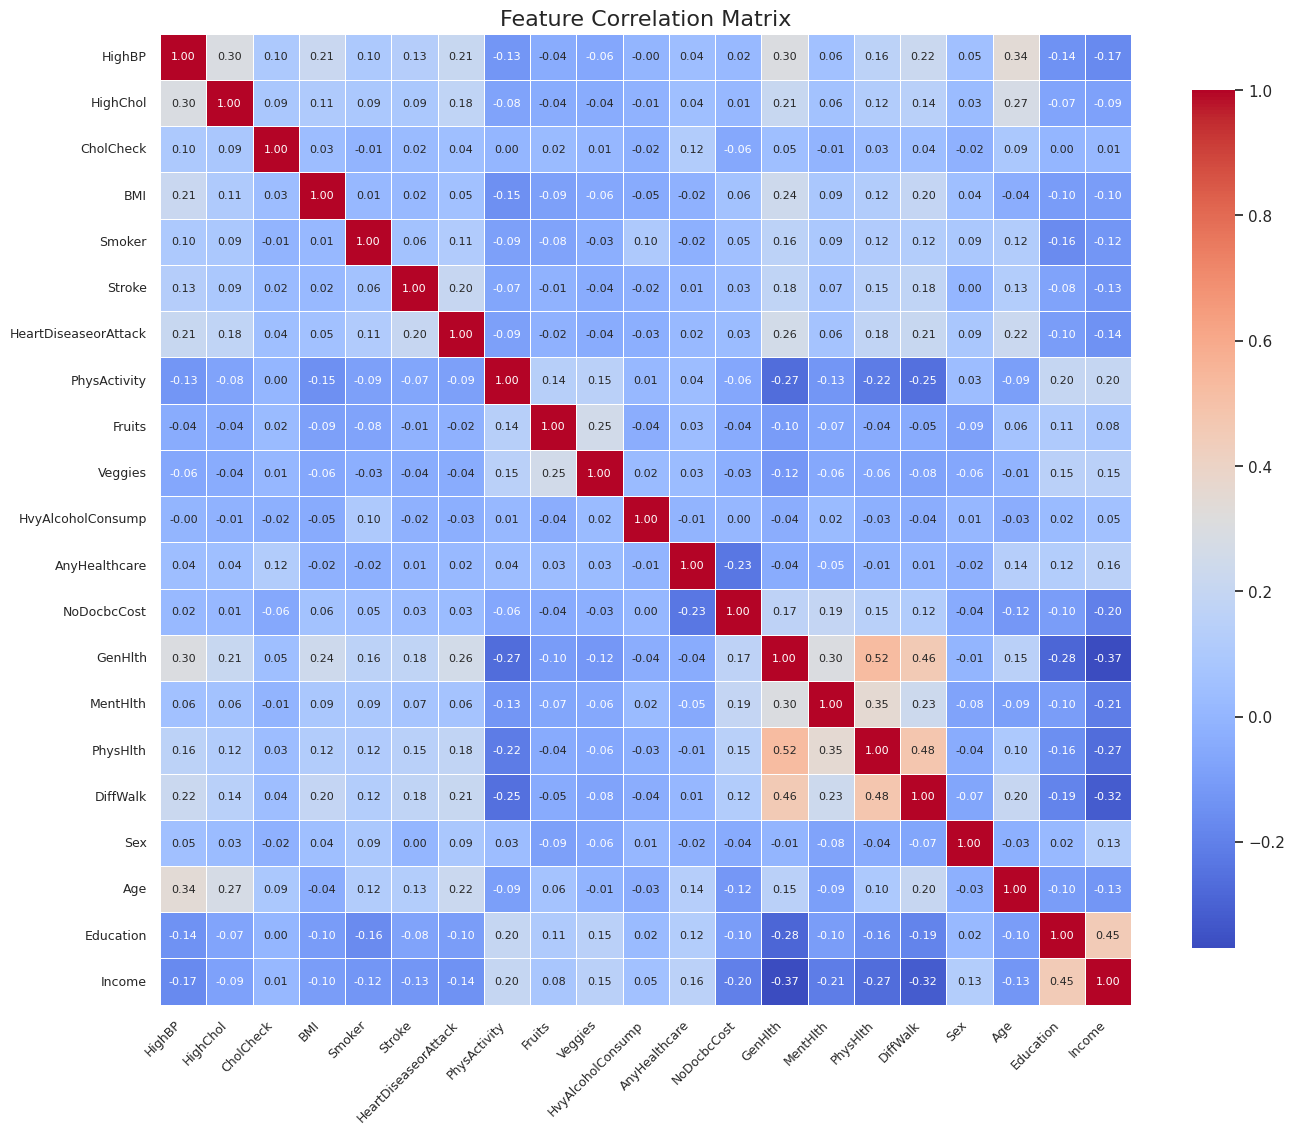

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))  # Adjust the figure size as needed
corr = X.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()



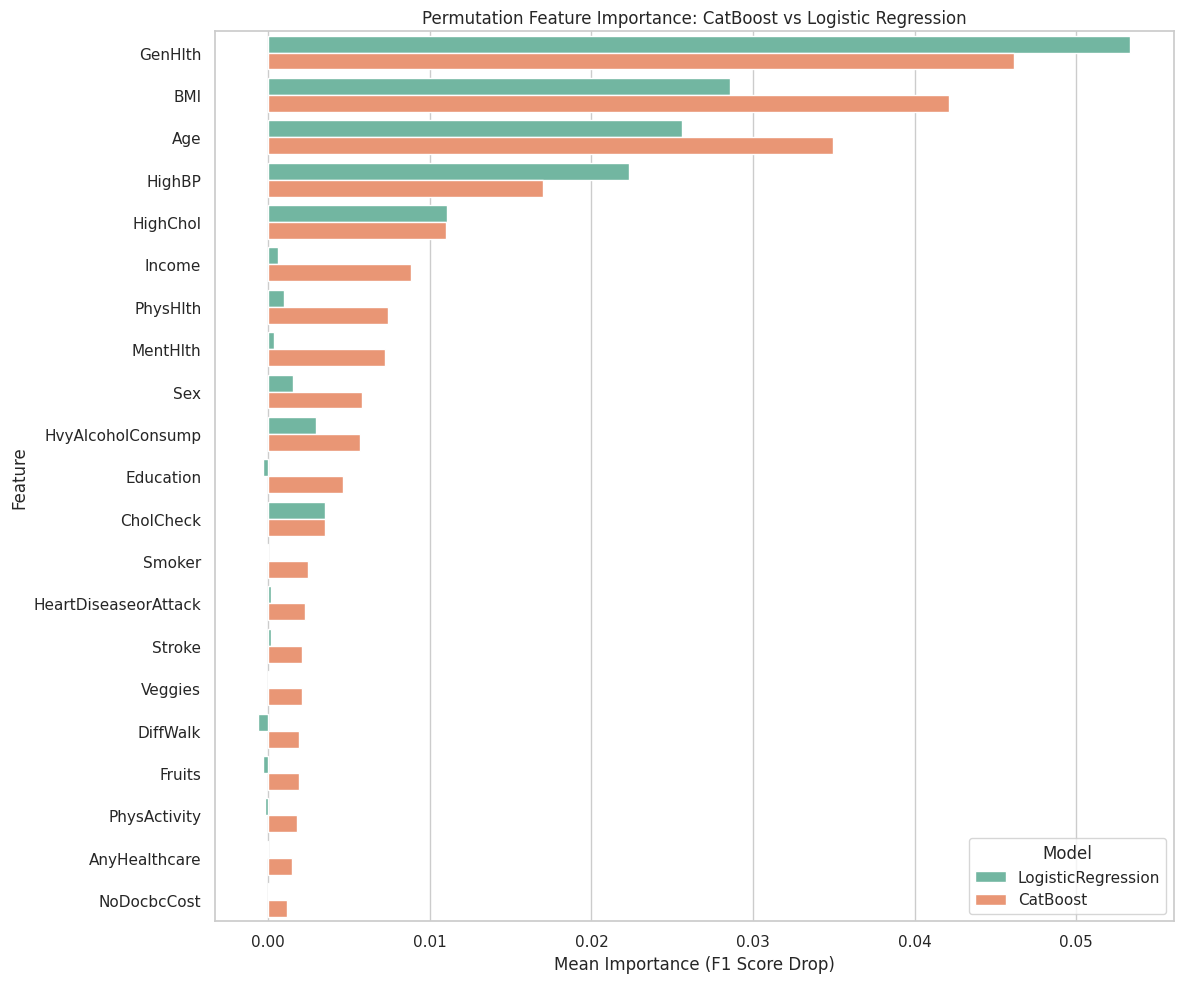

In [44]:
# Ensure target is 1D
y_bal_1d = y_bal.values.ravel()

# ------------------ CATBOOST MODEL ------------------
catboost_model = CatBoostClassifier(verbose=0, random_state=42)
catboost_model.fit(X_bal, y_bal_1d)

catboost_result = permutation_importance(
    catboost_model, X_bal, y_bal_1d, scoring='f1', n_repeats=5, random_state=42
)

catboost_importance = pd.DataFrame({
    'feature': X_bal.columns,
    'importance_mean': catboost_result.importances_mean,
    'importance_std': catboost_result.importances_std,
    'model': 'CatBoost'
})

# ------------------ LOGISTIC REGRESSION MODEL ------------------
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_bal, y_bal_1d)

logreg_result = permutation_importance(
    logreg_model, X_bal, y_bal_1d, scoring='f1', n_repeats=5, random_state=42
)

logreg_importance = pd.DataFrame({
    'feature': X_bal.columns,
    'importance_mean': logreg_result.importances_mean,
    'importance_std': logreg_result.importances_std,
    'model': 'LogisticRegression'
})

# ------------------ COMBINE & PLOT ------------------
importance_df = pd.concat([catboost_importance, logreg_importance])
importance_df = importance_df.sort_values(by='importance_mean', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(
    data=importance_df,
    x='importance_mean',
    y='feature',
    hue='model',
    errorbar=('sd'),
    palette='Set2'
)
plt.title('Permutation Feature Importance: CatBoost vs Logistic Regression')
plt.xlabel('Mean Importance (F1 Score Drop)')
plt.ylabel('Feature')
plt.legend(title='Model')
plt.tight_layout()
plt.show()



In [45]:
importance_df


,feature,importance_mean,importance_std,model
13,GenHlth,0.053358,0.001077,LogisticRegression
13,GenHlth,0.046169,0.000924,CatBoost
3,BMI,0.042102,0.000814,CatBoost
18,Age,0.034973,0.000699,CatBoost
3,BMI,0.028557,0.000943,LogisticRegression
18,Age,0.025606,0.001003,LogisticRegression
0,HighBP,0.022308,0.000756,LogisticRegression
0,HighBP,0.017001,0.000844,CatBoost
1,HighChol,0.011081,0.000786,LogisticRegression
1,HighChol,0.011015,0.000281,CatBoost


Selected features by RFE with CatBoost:
Index(['HighBP', 'HighChol', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Sex',
       'Age', 'Education', 'Income'],
      dtype='object')


<ipython-input-47-b1c572acbf53>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_ranking_df, x='ranking', y='feature', palette='viridis')


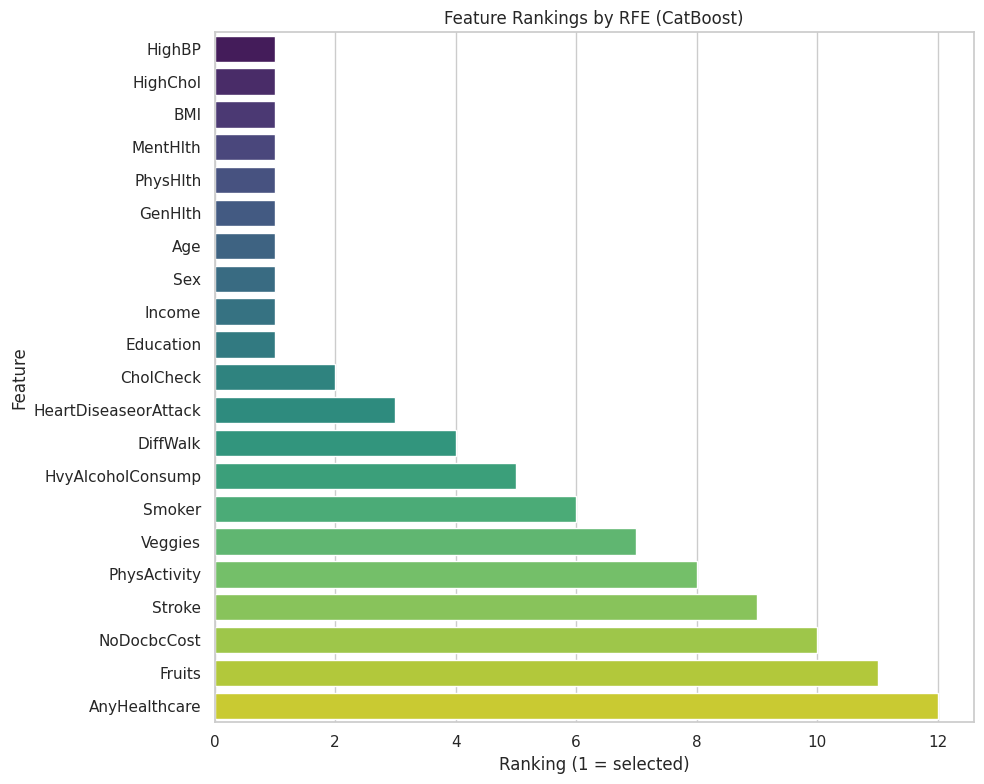

In [47]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure y is 1D
y_bal_1d = y_bal.values.ravel()

# Wrapper class for CatBoost to have feature_importances_ property (read-only)
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.model = CatBoostClassifier(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    @property
    def feature_importances_(self):
        return self.model.get_feature_importance()

# Instantiate the CatBoost wrapper
catboost_wrapper = CatBoostWrapper(random_state=42)

# Create RFE with CatBoost as the estimator
rfe_catboost = RFE(estimator=catboost_wrapper, n_features_to_select=10, step=1)

# Fit RFE on data
rfe_catboost.fit(X_bal, y_bal_1d)

# Extract selected features
selected_features = X_bal.columns[rfe_catboost.support_]

print("Selected features by RFE with CatBoost:")
print(selected_features)

# Optional: visualize ranking of features
feature_ranking_df = pd.DataFrame({
    'feature': X_bal.columns,
    'ranking': rfe_catboost.ranking_
}).sort_values('ranking')

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_ranking_df, x='ranking', y='feature', palette='viridis')
plt.title('Feature Rankings by RFE (CatBoost)')
plt.xlabel('Ranking (1 = selected)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


#Preprocessing nach feature testing


In [48]:
# --- Step 1: Define feature types ---
binary_features = [
    'HighBP',
    'HighChol',
    #'CholCheck',
    #'Smoker',
    #'Stroke',
    #'HeartDiseaseorAttack',
    #'PhysActivity',
    #'Fruits',
    #'Veggies',
    #'HvyAlcoholConsump',
    #'AnyHealthcare',
    #'NoDocbcCost',
    #'DiffWalk',
    'Sex'
]

ordinal_features = ['GenHlth',
                    'Age',
                    'Education',
                    'Income'
                    ]
ratio_features = ['BMI',
                  'MentHlth',
                  'PhysHlth'
                  ]

In [49]:
# --- Step 2: Define transformers ---
scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()

# Preprocessing pipeline for models that need scaling
preprocessor = ColumnTransformer([
    ('ratio', scaler, ratio_features),
    ('ordinal', ordinal_encoder, ordinal_features)
], remainder='passthrough')  # binary features remain untouched


rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X, Y)

In [50]:

# --- Step 3: Define models ---
models = [
    ("XGB", XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ("CB", CatBoostClassifier(learning_rate=0.11, max_depth=10, n_estimators=80, verbose=0)),
    ("RF", RandomForestClassifier()),
    ("GBC", GradientBoostingClassifier()),
    ("KNN", Pipeline([('preprocess', preprocessor), ('model', KNeighborsClassifier())])),
    #("SVC", Pipeline([('preprocess', preprocessor), ('model', SVC())]))
]

In [51]:
# --- Step 4: Evaluation setup ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

#next to do: drop features actually from X_bal, retrain, finetune etc.

#Model evaluation

In [56]:
print(X_bal)

        HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  \
9362         0         0          1   27       1       0   
1082         1         1          1   25       0       0   
148278       1         0          1   21       0       0   
57301        0         0          1   23       0       0   
127572       0         0          1   27       0       0   
...        ...       ...        ...  ...     ...     ...   
253659       0         1          1   37       0       0   
253668       0         1          1   29       1       0   
253670       1         1          1   25       0       0   
253676       1         1          1   18       0       0   
253679       1         1          1   25       0       0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  \
9362                       0             1       1        1  ...   
1082                       0             0       0        1  ...   
148278                     0             1       0        1  ...   
57301  

In [52]:
# --- Step 5: Run cross-validation ---

results = []
names = []

for name, model in models:
    scores = cross_val_score(model, X_bal, y_bal, cv=cv, scoring=scorer, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f"{name}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

XGB: F1 = 0.7562 ± 0.0040
CB: F1 = 0.7614 ± 0.0047
RF: F1 = 0.7454 ± 0.0055
GBC: F1 = 0.7604 ± 0.0043


KeyboardInterrupt: 

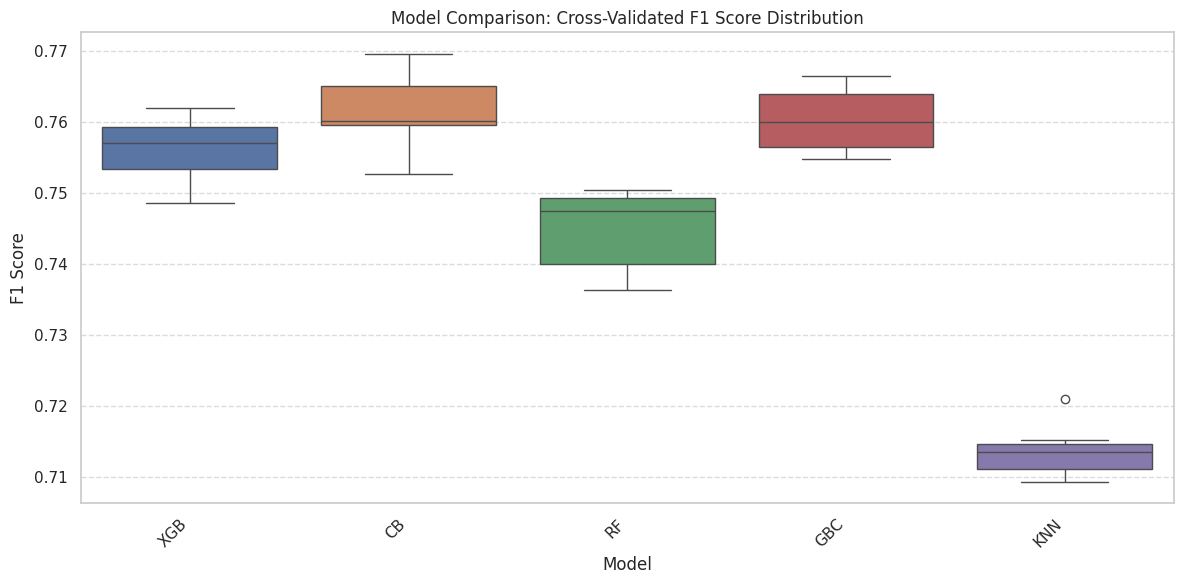

In [35]:
#Step 6 Boxplots

# Plot boxplot of the cross-validation F1 scores
plt.figure(figsize=(12, 6))
sns.boxplot(data=results)
plt.xticks(ticks=range(len(names)), labels=names, rotation=45, ha='right')
plt.title('Model Comparison: Cross-Validated F1 Score Distribution')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [36]:
#Additional models

models2 = [
    # Additional models
    ("LogisticRegression", Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=1000))])),
    ("LDA", Pipeline([('preprocessor', preprocessor), ('model', LinearDiscriminantAnalysis())])),
    ("NaiveBayes", Pipeline([('preprocessor', preprocessor), ('model', GaussianNB())])),
    ("ExtraTrees", ExtraTreesClassifier()),
    ("LightGBM", LGBMClassifier()),
    ("MLP", Pipeline([('preprocessor', preprocessor), ('model', MLPClassifier(max_iter=500))]))
]

# Evaluation setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

results2 = []
names2 = []

# Run cross-validation and print results
for name, model in models2:
    scores = cross_val_score(model, X_bal, y_bal, cv=cv, scoring=scorer, n_jobs=-1)
    results2.append(scores)
    names2.append(name)
    print(f"{name}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

LogisticRegression: F1 = 0.7496 ± 0.0052
LDA: F1 = 0.7521 ± 0.0062
NaiveBayes: F1 = 0.7126 ± 0.0052
ExtraTrees: F1 = 0.7322 ± 0.0061
LightGBM: F1 = 0.7625 ± 0.0043


KeyboardInterrupt: 

In [ ]:
#Boxplots 2

# Plot boxplot of the cross-validation F1 scores
plt.figure(figsize=(12, 6))
sns.boxplot(data=results2)
plt.xticks(ticks=range(len(names2)), labels=names2, rotation=45, ha='right')
plt.title('Model Comparison: Cross-Validated F1 Score Distribution')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#print(X_bal.columns.tolist())

'HighBP', - binary
'HighChol', - binary
'CholCheck', - binary (0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years)
'BMI', - Integer
'Smoker', - binary (Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes)
'Stroke', - binary
'HeartDiseaseorAttack', - binary
'PhysActivity', - binary
'Fruits', -binary
'Veggies', -binary
'HvyAlcoholConsump', -binary
'AnyHealthcare', -binary
'NoDocbcCost', -binary (Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no 1 = yes)
'GenHlth', -Integer (Would you say that in general your health is: scale 1-5 1 = excellent 2 = very good 3 = good 4 = fair 5 = poor)
'MentHlth', -Integer (ow thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? scale 1-30 days)
'PhysHlth', -Integer (Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? scale 1-30 days)
'DiffWalk', -binary
'Sex', -binary (0 = female 1 = male)
'Age', -Integer (13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older)
'Education', -Integer (Education level (EDUCA see codebook) scale 1-6 1 = Never attended school or only kindergarten 2 = Grades 1 through 8 (Elementary) 3 = Grades 9 through 11 (Some high school) 4 = Grade 12 or GED (High school graduate) 5 = College 1 year to 3 years (Some college or technical school) 6 = College 4 years or more (College graduate))
'Income' - Integer (Income scale (INCOME2 see codebook) scale 1-8 1 = less than $10,000 5 = less than $35,000 8 = $75,000 or more)


---> binarys: as is
---> Integers:



```
# Als Code formatiert
```

#Pipeline -Vergleich

In [10]:
# prepare configuration for cross validation test harness
seed = 7
# prepare models
models = []
models.append(("XGB", XGBClassifier()))
models.append(('CB', CatBoostClassifier(learning_rate=0.11, max_depth=12, n_estimators=80)))
#models.append(('LR', LogisticRegression()))
#models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
#models.append(('NB', GaussianNB()))
models.append(('GBC', GradientBoostingClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('SVC', SVC()))
# evaluate each model in turn
results = []
names = []
scoring = 'f1'
for name, model in models:
 kfold = model_selection.KFold(n_splits=10,shuffle=True, random_state=seed)
 cv_results = model_selection.cross_val_score(model, X_bal, y_bal, cv=kfold, scoring=scoring)
 results.append(cv_results)
 names.append(name)
 msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
 print(msg)

# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)

averages = [np.mean(result) for result in results]


for i, avg in enumerate(averages):
    ax.text(i + 1, avg, f'Avg: {avg:.6f}', ha='center', va='bottom', fontsize=8, color='blue')

plt.savefig('all_algos_boxplot_f1.png', bbox_inches='tight')

plt.show()

XGB: 0.756556 (0.005386)
0:	learn: 0.6522872	total: 319ms	remaining: 25.2s
1:	learn: 0.6174022	total: 549ms	remaining: 21.4s
2:	learn: 0.5889952	total: 730ms	remaining: 18.7s
3:	learn: 0.5686082	total: 974ms	remaining: 18.5s
4:	learn: 0.5535754	total: 1.11s	remaining: 16.7s
5:	learn: 0.5405772	total: 1.24s	remaining: 15.3s
6:	learn: 0.5299224	total: 1.36s	remaining: 14.2s
7:	learn: 0.5220069	total: 1.52s	remaining: 13.6s
8:	learn: 0.5152494	total: 1.76s	remaining: 13.9s
9:	learn: 0.5091839	total: 2.02s	remaining: 14.2s
10:	learn: 0.5029884	total: 2.29s	remaining: 14.4s
11:	learn: 0.4997454	total: 2.56s	remaining: 14.5s
12:	learn: 0.4958334	total: 2.75s	remaining: 14.2s
13:	learn: 0.4948813	total: 2.77s	remaining: 13.1s
14:	learn: 0.4903123	total: 3.07s	remaining: 13.3s
15:	learn: 0.4871702	total: 3.38s	remaining: 13.5s
16:	learn: 0.4843003	total: 3.69s	remaining: 13.7s
17:	learn: 0.4809493	total: 4s	remaining: 13.8s
18:	learn: 0.4781579	total: 4.28s	remaining: 13.8s
19:	learn: 0.476260

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

KNN: 0.709527 (0.005421)


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

KeyboardInterrupt: 